# Import all required libraries

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder


# TensorFlow/Keras imports

In [20]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.layers import Dense, Embedding, Conv1D, GlobalMaxPooling1D, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully!")

TensorFlow version: 2.18.0
All libraries imported successfully!


# Load and prepare datasets

In [22]:
train_df = pd.read_csv('dataEmotion/train.csv')
val_df = pd.read_csv('dataEmotion/val.csv')
test_df = pd.read_csv('dataEmotion/test.csv')

print("Dataset shapes:")
print(f"Train: {train_df.shape}")
print(f"Validation: {val_df.shape}")
print(f"Test: {test_df.shape}")


Dataset shapes:
Train: (16000, 2)
Validation: (2000, 2)
Test: (2000, 2)


# Check the data

In [23]:
print("First few rows of training data:")
print(train_df.head())
print("\nEmotion distribution:")
print(train_df['emotion'].value_counts())


First few rows of training data:
                                                text  emotion
0                            i didnt feel humiliated  sadness
1  i can go from feeling so hopeless to so damned...  sadness
2   im grabbing a minute to post i feel greedy wrong    anger
3  i am ever feeling nostalgic about the fireplac...     love
4                               i am feeling grouchy    anger

Emotion distribution:
emotion
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64


# Visualize emotion distribution (Train)

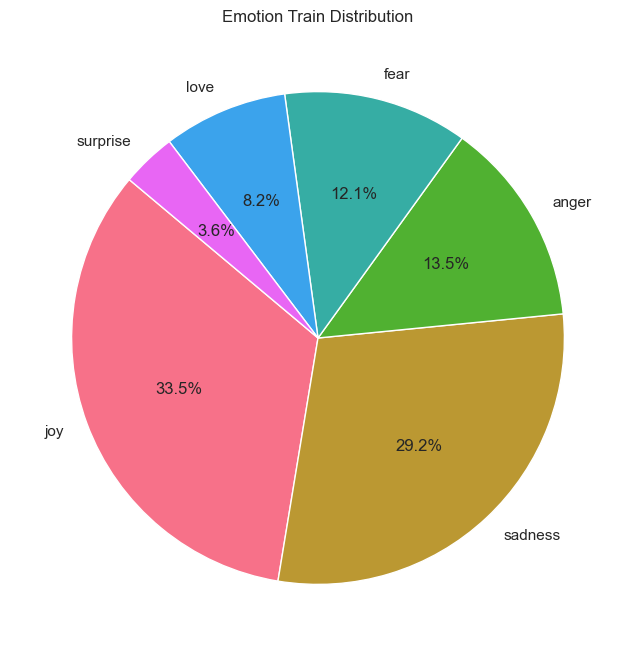

In [24]:
emotion_counts = train_df['emotion'].value_counts()
light_colors = sns.husl_palette(n_colors=len(emotion_counts))
sns.set(style="whitegrid")
plt.figure(figsize=(8, 8))
plt.pie(emotion_counts, labels=emotion_counts.index, autopct='%1.1f%%', startangle=140, colors=light_colors)
plt.title('Emotion Train Distribution')
plt.show()

# Filter out low-frequency emotions and balance dataset

In [25]:
print("Original emotion distribution:")
print(train_df['emotion'].value_counts())

# Remove love and surprise emotions from all datasets
train_df = train_df[~train_df['emotion'].isin(['love', 'surprise'])]
val_df = val_df[~val_df['emotion'].isin(['love', 'surprise'])]
test_df = test_df[~test_df['emotion'].isin(['love', 'surprise'])]

print("\nAfter filtering:")
print(train_df['emotion'].value_counts())


Original emotion distribution:
emotion
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

After filtering:
emotion
joy        5362
sadness    4666
anger      2159
fear       1937
Name: count, dtype: int64


# Balance the training dataset

In [26]:
print("Balancing the training dataset...")

# Get minimum count for balancing
min_count = train_df['emotion'].value_counts().min()
print(f"Minimum count per emotion: {min_count}")

# Sample each emotion to have the same number of instances
balanced_dfs = []
for emotion in train_df['emotion'].unique():
    emotion_df = train_df[train_df['emotion'] == emotion]
    # Sample with replacement if needed
    if len(emotion_df) >= min_count:
        sampled_df = emotion_df.sample(n=min_count, random_state=42)
    else:
        sampled_df = emotion_df.sample(n=min_count, random_state=42, replace=True)
    balanced_dfs.append(sampled_df)

# Combine balanced datasets
train_df_balanced = pd.concat(balanced_dfs, ignore_index=True)
train_df = train_df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("Balanced emotion distribution:")
print(train_df['emotion'].value_counts())

Balancing the training dataset...
Minimum count per emotion: 1937
Balanced emotion distribution:
emotion
sadness    1937
anger      1937
fear       1937
joy        1937
Name: count, dtype: int64


 # Visualize balanced distribution

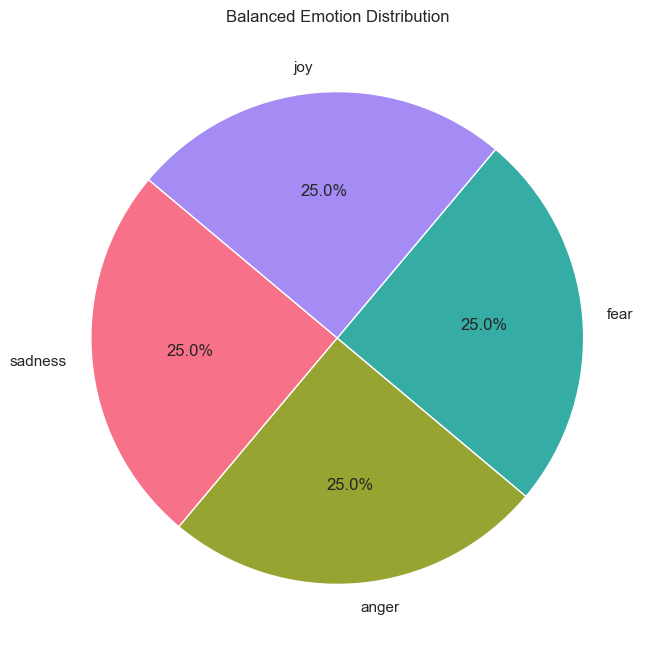

In [27]:
label_counts = train_df['emotion'].value_counts()
light_colors = sns.husl_palette(n_colors=len(label_counts))
plt.figure(figsize=(8, 8))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140, colors=light_colors)
plt.title('Balanced Emotion Distribution')
plt.show()


# Prepare data for training

In [28]:
# Extract text and labels
tr_text = train_df['text'].values
tr_emotion = train_df['emotion'].values

val_text = val_df['text'].values
val_emotion = val_df['emotion'].values

ts_text = test_df['text'].values
ts_emotion = test_df['emotion'].values

print(f"Training samples: {len(tr_text)}")
print(f"Validation samples: {len(val_text)}")
print(f"Test samples: {len(ts_text)}")

Training samples: 7748
Validation samples: 1741
Test samples: 1775


# Encode labels

In [29]:
# Encode emotions to numeric labels
encoder = LabelEncoder()
tr_label = encoder.fit_transform(tr_emotion)
val_label = encoder.transform(val_emotion)
ts_label = encoder.transform(ts_emotion)

print("Label encoding:")
print("Classes:", encoder.classes_)
print("Sample encoded labels:", tr_label[:5])

Label encoding:
Classes: ['anger' 'fear' 'joy' 'sadness']
Sample encoded labels: [3 3 0 1 3]


#  Text preprocessing and tokenization

In [30]:
# Create tokenizer
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(tr_text)

# Convert texts to sequences
tr_sequences = tokenizer.texts_to_sequences(tr_text)
val_sequences = tokenizer.texts_to_sequences(val_text)
ts_sequences = tokenizer.texts_to_sequences(ts_text)

# Pad sequences
max_length = 50
tr_x = pad_sequences(tr_sequences, maxlen=max_length, padding='post', truncating='post')
val_x = pad_sequences(val_sequences, maxlen=max_length, padding='post', truncating='post')
ts_x = pad_sequences(ts_sequences, maxlen=max_length, padding='post', truncating='post')

# Convert labels to categorical
num_classes = len(encoder.classes_)
tr_y = to_categorical(tr_label, num_classes=num_classes)
val_y = to_categorical(val_label, num_classes=num_classes)
ts_y = to_categorical(ts_label, num_classes=num_classes)

print(f"Vocabulary size: {len(tokenizer.word_index)}")
print(f"Max sequence length: {max_length}")
print(f"Number of classes: {num_classes}")
print(f"Training data shape: {tr_x.shape}")
print(f"Training labels shape: {tr_y.shape}")

Vocabulary size: 10165
Max sequence length: 50
Number of classes: 4
Training data shape: (7748, 50)
Training labels shape: (7748, 4)


# Build the model

In [31]:
def create_emotion_model(vocab_size, embedding_dim, max_length, num_classes):
    model = Sequential([
        # Embedding layer
        Embedding(vocab_size, embedding_dim, input_length=max_length),
        
        # Convolutional layers for feature extraction
        Conv1D(128, 5, activation='relu'),
        GlobalMaxPooling1D(),
        
        # Dense layers with dropout for classification
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        
        Dense(64, activation='relu'),
        Dropout(0.3),
        
        # Output layer
        Dense(num_classes, activation='softmax')
    ])
    
    return model

# Create the model
vocab_size = min(len(tokenizer.word_index) + 1, 10000)
embedding_dim = 100
model = create_emotion_model(vocab_size, embedding_dim, max_length, num_classes)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(), Recall()]
)

print("Model created successfully!")
print(model.summary())


Model created successfully!


c:\Users\bchal\anaconda3\envs\mindcare-ai\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


# Train the model

In [32]:
print("Starting model training...")

# Train the model
history = model.fit(
    tr_x, tr_y,
    batch_size=32,
    epochs=15,
    validation_data=(val_x, val_y),
    verbose=1
)

print("Training completed!")

Starting model training...
Epoch 1/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.3068 - loss: 1.4035 - precision: 0.3983 - recall: 0.0440 - val_accuracy: 0.5887 - val_loss: 1.2373 - val_precision: 1.0000 - val_recall: 0.0075
Epoch 2/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8406 - loss: 0.4597 - precision: 0.8941 - recall: 0.7647 - val_accuracy: 0.9104 - val_loss: 0.2773 - val_precision: 0.9359 - val_recall: 0.8891
Epoch 3/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9697 - loss: 0.1085 - precision: 0.9732 - recall: 0.9634 - val_accuracy: 0.8667 - val_loss: 0.4380 - val_precision: 0.8859 - val_recall: 0.8564
Epoch 4/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9826 - loss: 0.0678 - precision: 0.9852 - recall: 0.9805 - val_accuracy: 0.9184 - val_loss: 0.3055 - val_precision: 0.9266 - val_recall: 0.9133
Epoch 5/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9837 - loss: 0.0525 - precision: 0.9855 - recall: 0.9824 - val_a

# Evaluate the model

In [33]:
print("Evaluating model on test data...")

# Evaluate on test data
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(ts_x, ts_y, verbose=0)

print(f"\nTest Results:")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"Loss: {test_loss:.4f}")

# Get predictions for detailed evaluation
ts_pred = model.predict(ts_x)
ts_pred_classes = np.argmax(ts_pred, axis=1)
ts_true_classes = np.argmax(ts_y, axis=1)

# Classification report
print("\nDetailed Classification Report:")
print(classification_report(ts_true_classes, ts_pred_classes, target_names=encoder.classes_))


Evaluating model on test data...

Test Results:
Accuracy: 0.9414
Precision: 0.9424
Recall: 0.9397
Loss: 0.3031
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Detailed Classification Report:
              precision    recall  f1-score   support

       anger       0.88      0.95      0.91       275
        fear       0.89      0.93      0.91       224
         joy       0.96      0.98      0.97       695
     sadness       0.97      0.90      0.93       581

    accuracy                           0.94      1775
   macro avg       0.93      0.94      0.93      1775
weighted avg       0.94      0.94      0.94      1775



# Plot training history

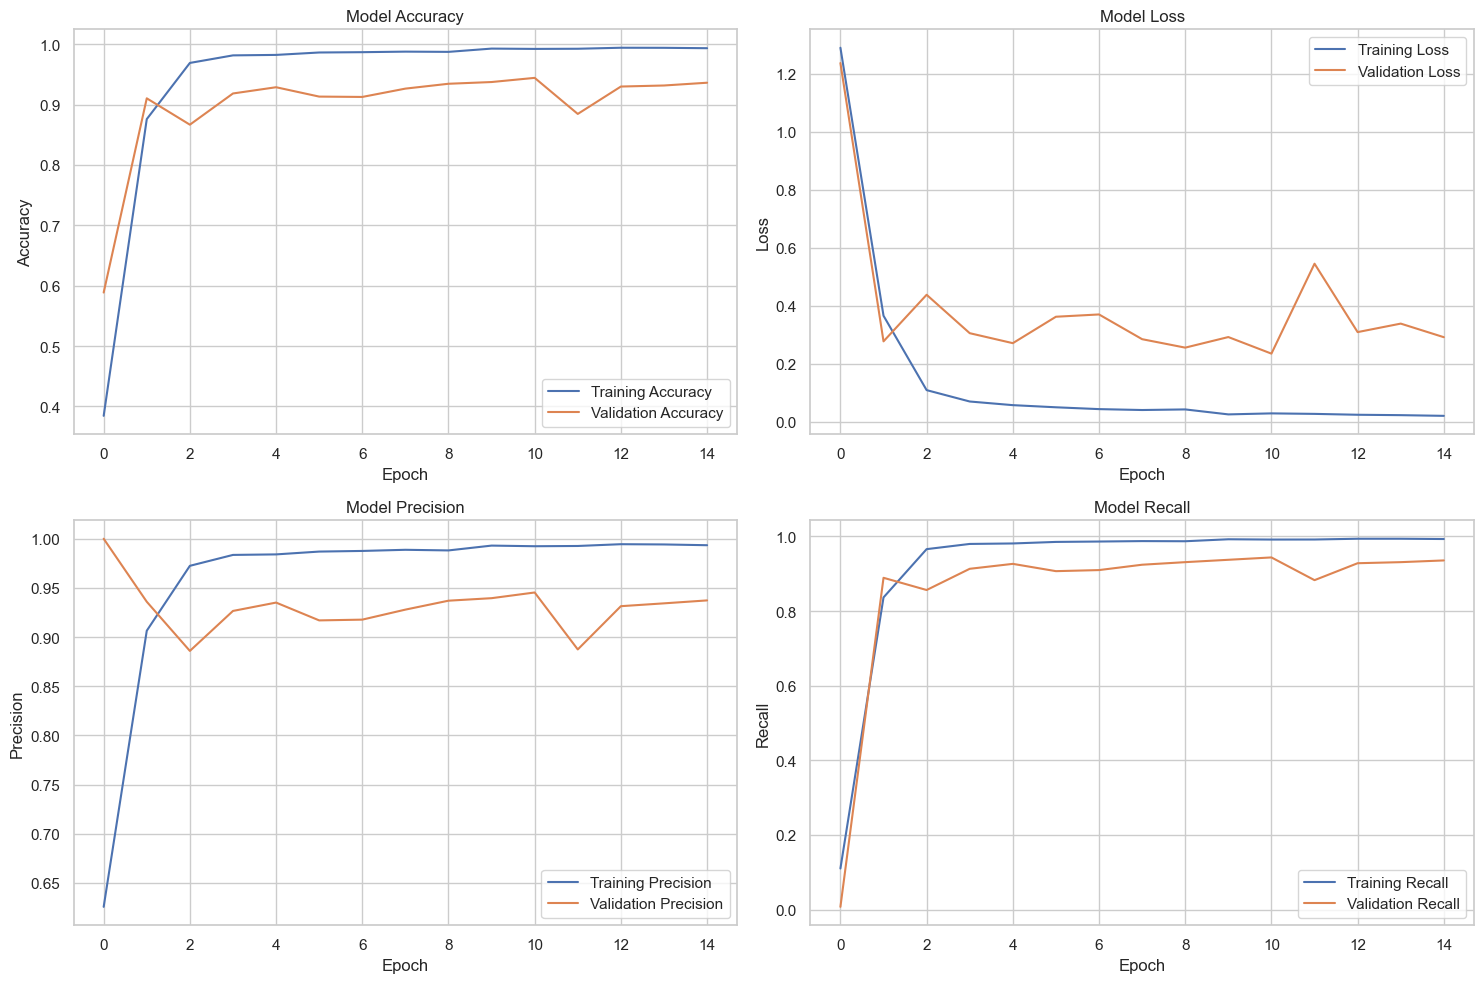

In [34]:
def plot_training_history(history):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Accuracy
    axes[0, 0].plot(history.history['accuracy'], label='Training Accuracy')
    axes[0, 0].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[0, 0].set_title('Model Accuracy')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    
    # Loss
    axes[0, 1].plot(history.history['loss'], label='Training Loss')
    axes[0, 1].plot(history.history['val_loss'], label='Validation Loss')
    axes[0, 1].set_title('Model Loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    
    # Precision
    axes[1, 0].plot(history.history['precision'], label='Training Precision')
    axes[1, 0].plot(history.history['val_precision'], label='Validation Precision')
    axes[1, 0].set_title('Model Precision')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].legend()
    
    # Recall
    axes[1, 1].plot(history.history['recall'], label='Training Recall')
    axes[1, 1].plot(history.history['val_recall'], label='Validation Recall')
    axes[1, 1].set_title('Model Recall')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].legend()
    
    plt.tight_layout()
    plt.show()

plot_training_history(history)

# Confusion Matrix

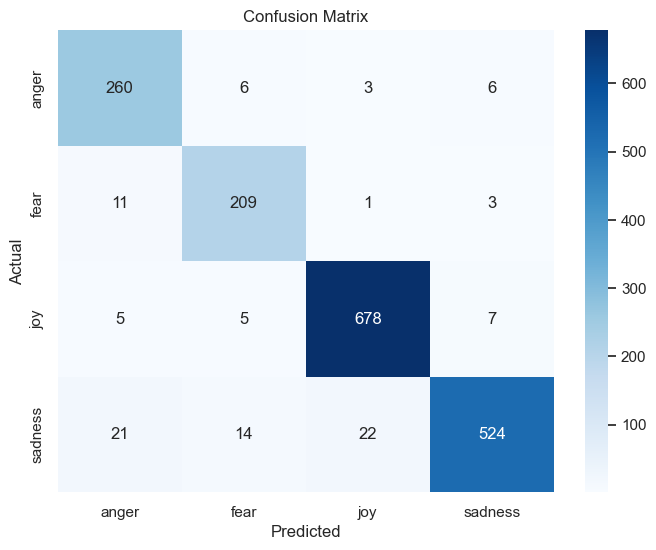

In [35]:
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

plot_confusion_matrix(ts_true_classes, ts_pred_classes, encoder.classes_)


# Save the model and preprocessing objects

In [36]:
print("Saving model and preprocessing objects...")

# Save the model
model.save('emotion_model.h5')
print("Model saved as 'emotion_model.h5'")

# Save tokenizer
import pickle
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("Tokenizer saved as 'tokenizer.pkl'")

# Save label encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(encoder, f)
print("Label encoder saved as 'label_encoder.pkl'")

# Save model configuration for easy loading
config = {
    'vocab_size': vocab_size,
    'embedding_dim': embedding_dim,
    'max_length': max_length,
    'num_classes': num_classes,
    'emotions': list(encoder.classes_)
}

with open('model_config.pkl', 'wb') as f:
    pickle.dump(config, f)
print("Model configuration saved as 'model_config.pkl'")

print("\nAll files saved successfully!")
print("Files created:")
print("- emotion_model.h5")
print("- tokenizer.pkl") 
print("- label_encoder.pkl")
print("- model_config.pkl")


Saving model and preprocessing objects...
Model saved as 'emotion_model.h5'
Tokenizer saved as 'tokenizer.pkl'
Label encoder saved as 'label_encoder.pkl'
Model configuration saved as 'model_config.pkl'

All files saved successfully!
Files created:
- emotion_model.h5
- tokenizer.pkl
- label_encoder.pkl
- model_config.pkl


# Test the model with sample texts

In [37]:
def test_model_predictions():
    test_texts = [
        "I'm feeling really sad today",
        "I'm so happy and excited!",
        "This is making me angry",
        "I'm worried about the future",
        "I feel amazing and full of energy",
        "I'm scared about what might happen"
    ]
    
    print("Testing model with sample texts:")
    print("-" * 50)
    
    for text in test_texts:
        # Preprocess the text
        sequence = tokenizer.texts_to_sequences([text])
        padded = pad_sequences(sequence, maxlen=max_length)
        
        # Predict
        prediction = model.predict(padded, verbose=0)
        predicted_class = np.argmax(prediction)
        confidence = prediction[0][predicted_class]
        emotion = encoder.inverse_transform([predicted_class])[0]
        
        print(f"Text: '{text}'")
        print(f"Predicted emotion: {emotion} (confidence: {confidence:.3f})")
        print()

test_model_predictions()

Testing model with sample texts:
--------------------------------------------------
Text: 'I'm feeling really sad today'
Predicted emotion: sadness (confidence: 0.935)

Text: 'I'm so happy and excited!'
Predicted emotion: joy (confidence: 0.958)

Text: 'This is making me angry'
Predicted emotion: anger (confidence: 0.880)

Text: 'I'm worried about the future'
Predicted emotion: sadness (confidence: 0.983)

Text: 'I feel amazing and full of energy'
Predicted emotion: joy (confidence: 1.000)

Text: 'I'm scared about what might happen'
Predicted emotion: fear (confidence: 1.000)

